In [1]:
import pandas as pd
import numpy as np
from scipy import stats

In [2]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.["Sales"].describe()

SyntaxError: invalid syntax (2266193387.py, line 1)

In [4]:
df["Sales"].describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

In [5]:
print("Median:", df["Sales"].median())

Median: 54.489999999999995


In [6]:
print(df["Category"].mode())

0    Office Supplies
Name: Category, dtype: object


In [7]:
print("Skewness:", df["Sales"].skew())

Skewness: 12.97275234181623


In [8]:
tech = df[df["Category"]=="Technology"]["Sales"]
furniture = df[df["Category"]=="Furniture"]["Sales"]

t_stat, p_val = stats.ttest_ind(tech, furniture)

print("T Statistic:", t_stat)
print("P Value:", p_val)

T Statistic: 3.8430849029195886
P Value: 0.00012339952945434135


In [9]:
if p_val < 0.05:
    print("Significant Difference")
else:
    print("No Significant Difference")

Significant Difference


In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [11]:
ts = df.groupby("Order Date")["Sales"].sum()

In [12]:
monthly_sales = ts.resample("M").sum()
monthly_sales.head()

C:\Users\kasar\AppData\Local\Temp\ipykernel_7560\2643710872.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = ts.resample("M").sum()


Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

In [13]:
import matplotlib.pyplotas plt
monthly_sales.plot(figsize = (10,5))
plt.title("Monthly Sales Trend")
plt.show()

SyntaxError: invalid syntax (431997788.py, line 1)

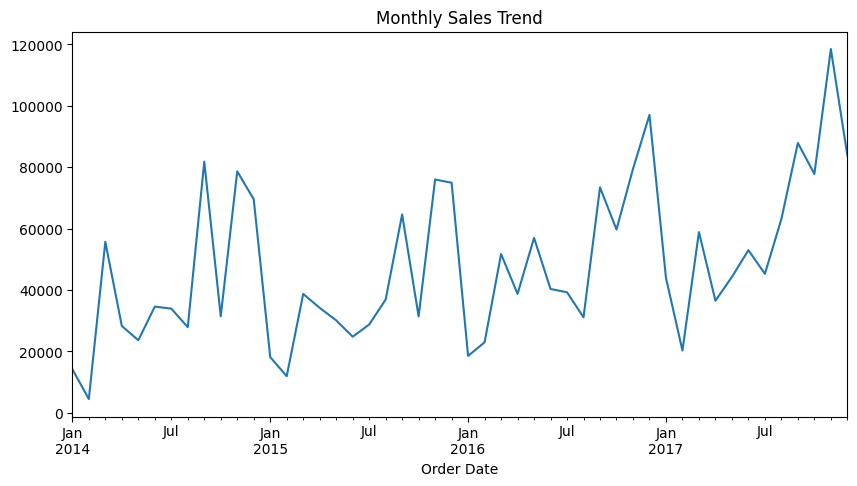

In [14]:
import matplotlib.pyplot as plt
monthly_sales.plot(figsize = (10,5))
plt.title("Monthly Sales Trend")
plt.show()

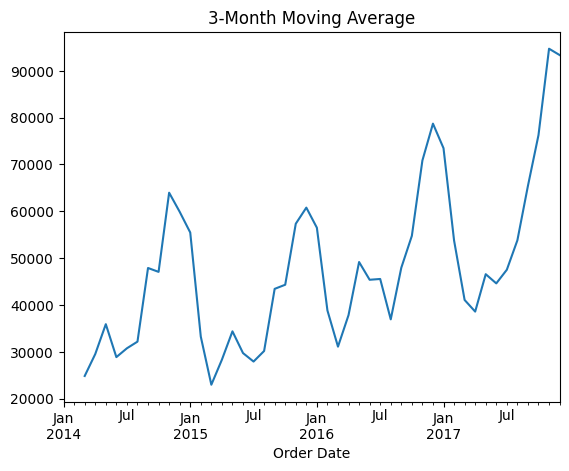

In [15]:
monthly_sales.rolling(3).mean().plot()
plt.title("3-Month Moving Average")
plt.show()

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [17]:
cluster_data = df[["Sales", "Profit", "Quantity"]]

In [18]:
scalar = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

NameError: name 'scaler' is not defined

In [19]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

In [20]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

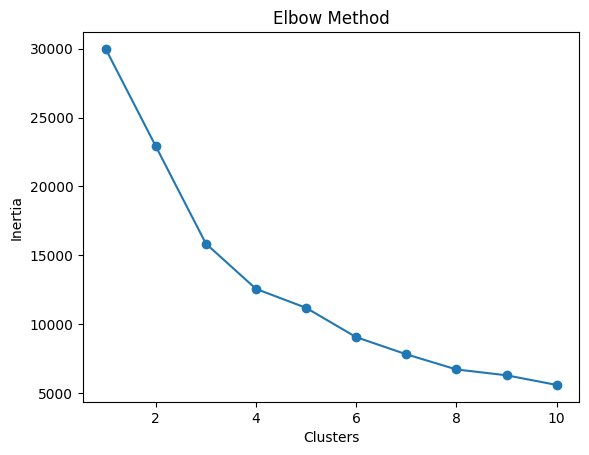

In [21]:
import matplotlib.pyplot as plt

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [22]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
df["Cluster"] = Kmeans.fit_predict(scaled_data)

NameError: name 'Kmeans' is not defined

In [23]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

In [24]:
from sklearn.decomposition import PCA

In [25]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

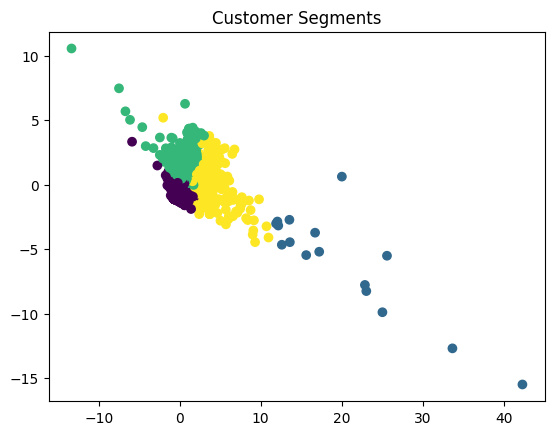

In [26]:
plt.scatter(pca_data[:,0],pca_data[:,1],c=df["Cluster"])
plt.title("Customer Segments")
plt.show()

In [27]:
X = df[["Profit", "Quantity", "Discount"]]
Y = df["Sales"]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression model = LinearRegression()
model.fit(X_train, Y_train)

SyntaxError: invalid syntax (58332576.py, line 1)

In [30]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
Y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [36]:
print("R2 Score:", r2_score(Y_test, Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))

R2 Score: -0.15181720106064533
MAE: 245.07556984450247
RMSE: 824.8499599151127


In [37]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,Discount,249.571780
1,Quantity,41.550264
0,Profit,1.561674


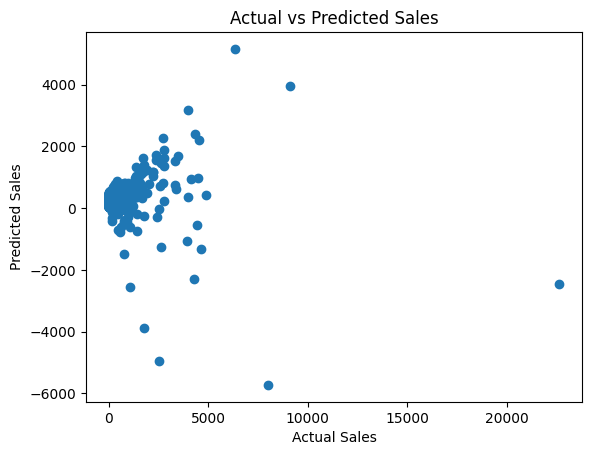

In [39]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()